### 1. SETUP Y CONFIGURACIÓN


##### 1.1 Imports

In [1]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# Image processing
from PIL import Image
from skimage import color, io
import cv2

# Metrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Utils
import warnings
warnings.filterwarnings('ignore')

# Verificar versiones
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from utils import rgb_to_lab, lab_to_rgb, normalize_lab, denormalize_lab

PyTorch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128
CUDA available: True


##### 1.2 Configuración de Seeds


In [ ]:
def set_seed(seed=42):
    """
    Configura seeds para reproducibilidad.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed configurada: {seed}")

# Aplicar seed
set_seed(12)

Seed configurada: 12


##### 1.3 Hiperparámetros Globales


In [ ]:
class Config:
    """
    Configuración global del proyecto.
    """
    # Paths
    DATA_DIR = Path("data/raw")
    SAMPLES_DIR = Path("data/samples")
    
    # Dataset
    IMG_SIZE = 256  
    BATCH_SIZE = 32  
    NUM_WORKERS = 4  
    
    # Training
    NUM_EPOCHS = 3  
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Model
    BACKBONE = "resnet18"  
    PRETRAINED = True
    
    # Early stopping
    PATIENCE = 10
    
    # Reproducibilidad
    SEED = 12

config = Config()

print(" Configuración:")
print(f"  - Tamaño de imagen: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  - Batch size: {config.BATCH_SIZE}")
print(f"  - Learning rate: {config.LEARNING_RATE}")
print(f"  - Backbone: {config.BACKBONE}")
print(f"  - Epochs: {config.NUM_EPOCHS}")

 Configuración:
  - Tamaño de imagen: 256x256
  - Batch size: 32
  - Learning rate: 0.001
  - Backbone: resnet18
  - Epochs: 3


### 2. EXPLORACIÓN Y PREPARACIÓN DEL DATASET



#### 2.1 Verificación del Dataset

In [4]:
dataset_path = Path("data/raw/imagewoof2-320")
assert dataset_path.exists(), "Dataset no encontrado. Descargar primero."

train_path = dataset_path / "train"
val_path = dataset_path / "val"

print("Dataset encontrado")
print(f"Train path: {train_path}")
print(f"Val path: {val_path}")

# Ver las clases de perros
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
print(f"\nClases de perros ({len(classes)}):")
for cls in classes:
    print(f"  - {cls}")

Dataset encontrado
Train path: data/raw/imagewoof2-320/train
Val path: data/raw/imagewoof2-320/val

Clases de perros (10):
  - n02086240
  - n02087394
  - n02088364
  - n02089973
  - n02093754
  - n02096294
  - n02099601
  - n02105641
  - n02111889
  - n02115641


#### 2.2 Exploración del Dataset


In [5]:
import glob

# Contar imágenes
train_images = glob.glob(str(train_path / "*" / "*.JPEG"))
val_images = glob.glob(str(val_path / "*" / "*.JPEG"))

print(f"Total imágenes de entrenamiento: {len(train_images)}")
print(f"Total imágenes de validación: {len(val_images)}")

# Clases disponibles
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
print(f"\nNúmero de clases: {len(classes)}")
print(f"Clases: {classes}")

# Distribución por clase
print("\nDistribución por clase (train):")
for cls in classes:
    n_images = len(list((train_path / cls).glob("*.JPEG")))
    print(f"  {cls}: {n_images} imágenes")

Total imágenes de entrenamiento: 9025
Total imágenes de validación: 3929

Número de clases: 10
Clases: ['n02086240', 'n02087394', 'n02088364', 'n02089973', 'n02093754', 'n02096294', 'n02099601', 'n02105641', 'n02111889', 'n02115641']

Distribución por clase (train):
  n02086240: 941 imágenes
  n02087394: 942 imágenes
  n02088364: 932 imágenes
  n02089973: 580 imágenes
  n02093754: 949 imágenes
  n02096294: 943 imágenes
  n02099601: 949 imágenes
  n02105641: 928 imágenes
  n02111889: 921 imágenes
  n02115641: 940 imágenes


In [6]:
# %%
# Mapping clase (folder) -> índice numérico y viceversa
class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(classes))}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

print("Mapping clase -> idx:")
for cls_name, idx in class_to_idx.items():
    print(f"  {cls_name} -> {idx}")


Mapping clase -> idx:
  n02086240 -> 0
  n02087394 -> 1
  n02088364 -> 2
  n02089973 -> 3
  n02093754 -> 4
  n02096294 -> 5
  n02099601 -> 6
  n02105641 -> 7
  n02111889 -> 8
  n02115641 -> 9


#### 2.3 Visualización de Ejemplos RGB


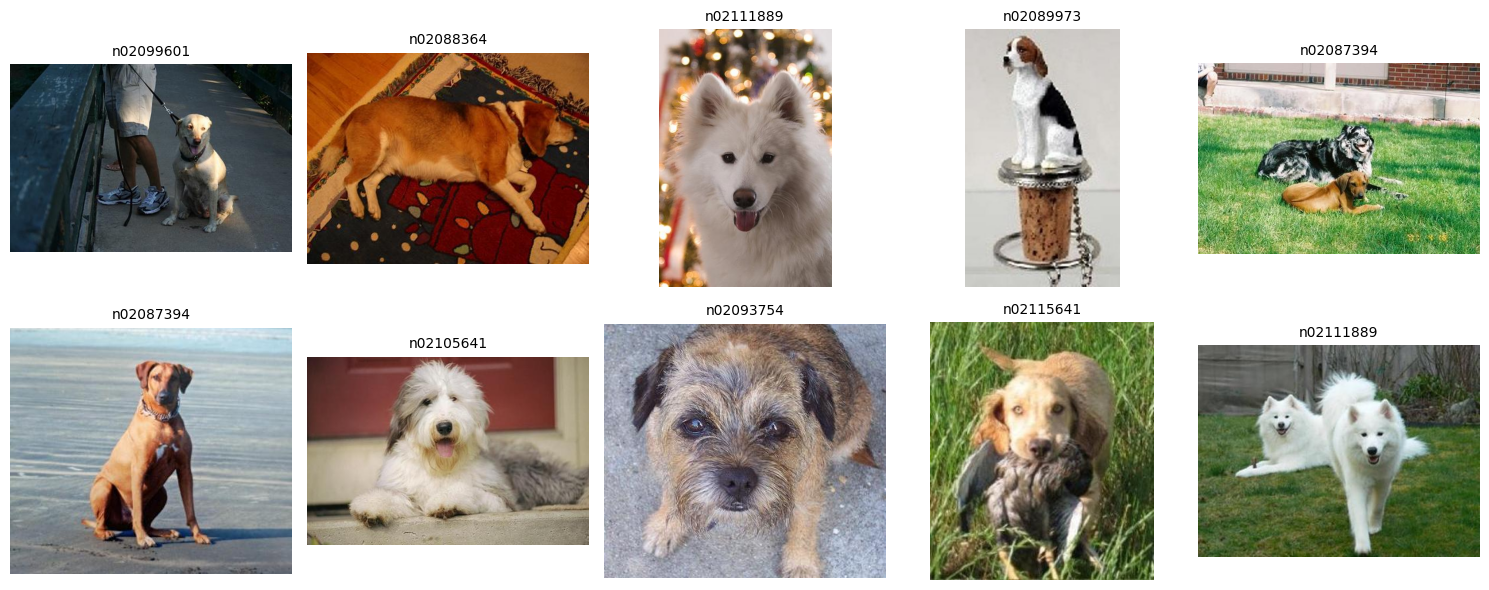

In [8]:
def visualize_random_samples(n_samples=10):
    """
    Visualiza muestras aleatorias del dataset.
    """
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    for idx, img_path in enumerate(random_images):
        img = Image.open(img_path).convert('RGB')
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = class_id
        
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=10)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_random_samples(10)

#### 2.4 Conversión RGB → Grayscale → LAB

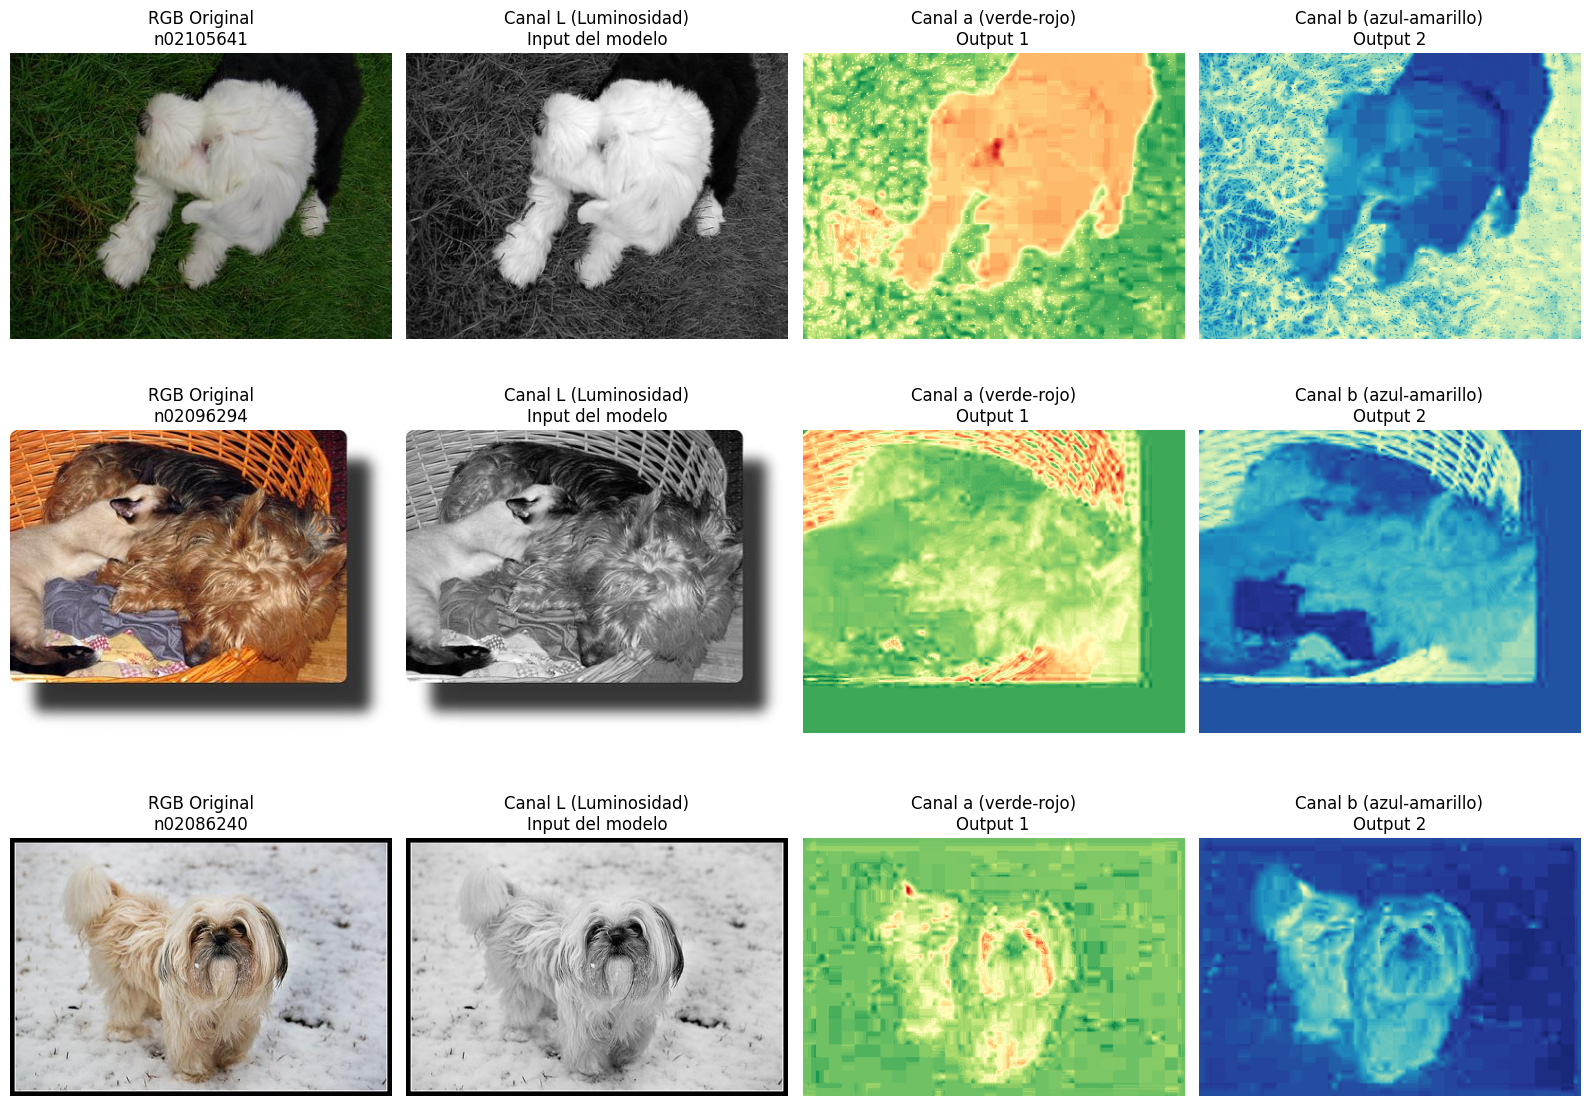

In [9]:
def visualize_color_spaces(n_samples=3):
    """
    Visualiza el proceso de conversión de espacios de color.
    """
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    for row, img_path in enumerate(random_images):
        # Cargar imagen RGB
        img_rgb = np.array(Image.open(img_path).convert('RGB')) / 255.0
        
        # Convertir a LAB
        img_lab = color.rgb2lab(img_rgb)
        
        # Extraer canales
        L = img_lab[:, :, 0]  # Luminosidad (grayscale)
        a = img_lab[:, :, 1]  # Canal a
        b = img_lab[:, :, 2]  # Canal b
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = class_id
        
        # Plot
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'RGB Original\n{class_name}')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(L, cmap='gray')
        axes[row, 1].set_title('Canal L (Luminosidad)\nInput del modelo')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(a, cmap='RdYlGn_r')
        axes[row, 2].set_title('Canal a (verde-rojo)\nOutput 1')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(b, cmap='YlGnBu_r')
        axes[row, 3].set_title('Canal b (azul-amarillo)\nOutput 2')
        axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_color_spaces(3)

### 3. DATA PIPELINE



In [10]:
class ColorizationDatasetWithLabels(Dataset):
    """
    Dataset para colorización de imágenes + clasificación de clase.
    
    Input:
        - L (canal de luminancia)  -> (1, H, W)
    Targets:
        - ab (canales de color)    -> (2, H, W)
        - label (índice de clase)  -> int en [0, num_clases-1]
    """
    def __init__(self, image_paths, class_to_idx, transform=None, img_size=256):
        self.image_paths = image_paths
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.img_size = img_size
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        # Cargar imagen RGB
        img_rgb = Image.open(img_path).convert('RGB')
        img_rgb = img_rgb.resize((self.img_size, self.img_size), Image.BICUBIC)
        img_rgb = np.array(img_rgb) / 255.0
        
        # Data augmentation
        if self.transform:
            img_rgb = self.transform(img_rgb)
        
        # RGB -> LAB
        img_lab = rgb_to_lab(img_rgb)
        L = img_lab[:, :, 0:1]   # (H,W,1)
        ab = img_lab[:, :, 1:]   # (H,W,2)
        
        # Normalización
        L = L / 100.0            
        ab = ab / 128.0          
        
        # Tensores (C,H,W)
        L  = torch.from_numpy(L.transpose(2, 0, 1)).float()
        ab = torch.from_numpy(ab.transpose(2, 0, 1)).float()
        
        # Label de clase según carpeta
        class_id = Path(img_path).parent.name  
        label = self.class_to_idx[class_id]
        label = torch.tensor(label, dtype=torch.long)
        
        return L, ab, label


print("ColorizationDatasetWithLabels definido.")


ColorizationDatasetWithLabels definido.


#### 3.1 Data Augmentation


In [11]:
class ImageAugmentation:
    """
    Data augmentation para imágenes RGB.
    Se aplica ANTES de convertir a LAB.
    """
    
    def __init__(self, p=0.5):
        """
        Args:
            p: probabilidad de aplicar cada transformación
        """
        self.p = p
    
    def __call__(self, img):
        """
        Args:
            img: numpy array (H, W, 3) en rango [0, 1]
        
        Returns:
            img_aug: numpy array aumentado
        """
        # Horizontal flip
        if np.random.random() < self.p:
            img = np.fliplr(img)
        
        # Ajustes de brillo (pequeños)
        if np.random.random() < self.p:
            factor = np.random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 1)
        
        # Ajustes de contraste (pequeños)
        if np.random.random() < self.p:
            factor = np.random.uniform(0.8, 1.2)
            mean = img.mean()
            img = np.clip((img - mean) * factor + mean, 0, 1)
        
        return img

# Crear transformación
train_transform = ImageAugmentation(p=0.5)

print("Data augmentation configurado")
print("Transformaciones: horizontal flip, ajuste de brillo, ajuste de contraste")

Data augmentation configurado
Transformaciones: horizontal flip, ajuste de brillo, ajuste de contraste


In [14]:
# Cargar ResNet18 preentrenado en ImageNet
backbone = models.resnet18(pretrained=True)

# Ver la arquitectura
print("Arquitectura de ResNet18:")
print(backbone)
print("\n" + "="*50)

# Congelar todos los parámetros
for param in backbone.parameters():
    param.requires_grad = False

print("Todos los parámetros del backbone congelados")

# Verificar qué parámetros son entrenables
trainable_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in backbone.parameters())

print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros totales: {total_params:,}")

Arquitectura de ResNet18:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (re

In [15]:
# Mover a device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
class WeightedMSELoss(nn.Module):
    """
    MSE con peso mayor en valores alejados de 0.
    Penaliza más cuando el modelo predice neutral en zonas coloridas.
    """
    def __init__(self):
        super(WeightedMSELoss, self).__init__()
    
    def forward(self, pred, target):
        # Peso basado en la magnitud del target
        # Si el target es colorido (lejos de 0), peso mayor
        magnitude = torch.sqrt(target[:, 0]**2 + target[:, 1]**2)  # Magnitud en espacio ab
        weight = 1.0 + 2.0 * magnitude  # Peso entre 1 y 3
        
        # MSE ponderado
        mse = (pred - target) ** 2
        weighted_mse = mse * weight.unsqueeze(1)
        
        return weighted_mse.mean()


# Crear nueva loss
criterion_weighted = WeightedMSELoss()

print("Nueva función de pérdida: MSE ponderado por saturación del color")

Nueva función de pérdida: MSE ponderado por saturación del color


#### 4 Setup para Modelado

Generados 400 bins de color válidos (de 400 candidatos)
Número de clases de color: Q = 400
Primeros 10 bins:
[[-110.        -110.       ]
 [-110.         -98.42105  ]
 [-110.         -86.8421   ]
 [-110.         -75.26316  ]
 [-110.         -63.68421  ]
 [-110.         -52.105263 ]
 [-110.         -40.526318 ]
 [-110.         -28.947369 ]
 [-110.         -17.368422 ]
 [-110.          -5.7894735]]


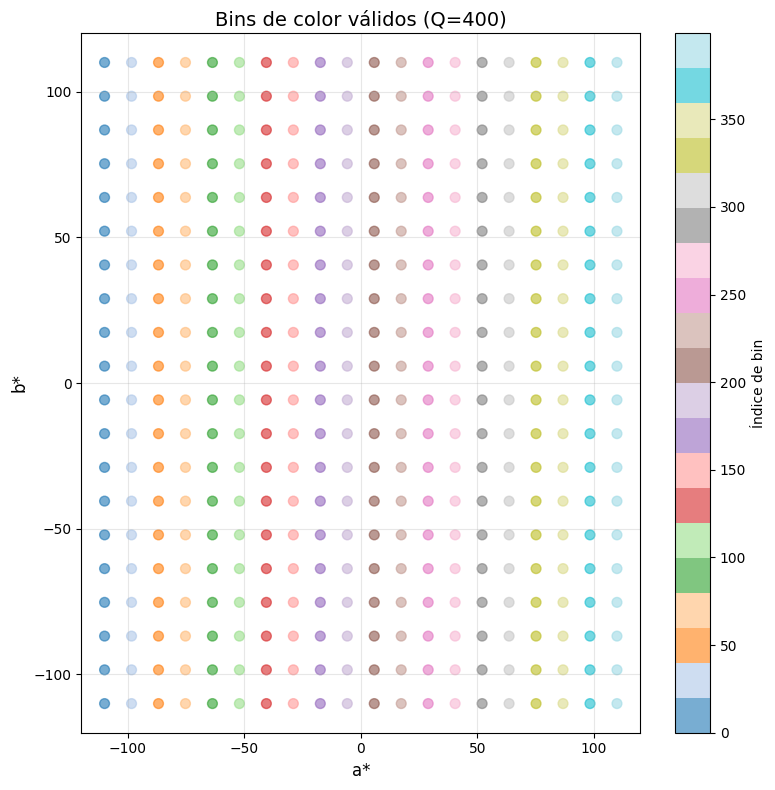

Bins guardados en pts_ab_torch: torch.Size([400, 2])


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from skimage import color
import matplotlib.pyplot as plt

def generate_ab_bins(grid_size=20, L_value=50):
    """
    Genera una grilla uniforme de bins en espacio ab
    y filtra los que son válidos (dentro del gamut RGB).
    
    Args:
        grid_size: número de divisiones por eje (a y b)
        L_value: valor de luminancia para verificar gamut
    
    Returns:
        pts_ab: array (Q, 2) con centros de bins válidos
    """
    # Grilla uniforme en [-110, 110] para a y b
    a_range = np.linspace(-110, 110, grid_size)
    b_range = np.linspace(-110, 110, grid_size)
    
    pts_ab_list = []
    
    for a in a_range:
        for b in b_range:
            # Crear punto LAB
            lab_point = np.array([[[L_value, a, b]]], dtype=np.float32)
            
            # Intentar convertir a RGB
            try:
                rgb_point = color.lab2rgb(lab_point)
                
                if np.all(rgb_point >= 0) and np.all(rgb_point <= 1):
                    pts_ab_list.append([a, b])
            except:
                pass
    
    pts_ab = np.array(pts_ab_list, dtype=np.float32)
    
    print(f"Generados {len(pts_ab)} bins de color válidos (de {grid_size**2} candidatos)")
    
    return pts_ab

# Generar bins
pts_ab_np = generate_ab_bins(grid_size=20, L_value=50)
pts_ab_torch = torch.from_numpy(pts_ab_np)
Q = pts_ab_torch.shape[0]

print(f"Número de clases de color: Q = {Q}")
print(f"Primeros 10 bins:\n{pts_ab_np[:10]}")

# Visualizar distribución de bins
plt.figure(figsize=(8, 8))
plt.scatter(pts_ab_np[:, 0], pts_ab_np[:, 1], c=range(len(pts_ab_np)), 
            cmap='tab20', s=50, alpha=0.6)
plt.xlabel('a*', fontsize=12)
plt.ylabel('b*', fontsize=12)
plt.title(f'Bins de color válidos (Q={Q})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-120, 120)
plt.ylim(-120, 120)
plt.colorbar(label='Índice de bin')
plt.tight_layout()
plt.savefig('color_bins_distribution.png', dpi=150)
plt.show()

print(f"Bins guardados en pts_ab_torch: {pts_ab_torch.shape}")

#### 4.1 - Cuantización por chunks

In [18]:
class ColorizationDatasetQuantizedFast(Dataset):
    """
    Dataset optimizado: devuelve ab continuo, la cuantización se hace en batch en GPU
    """
    def __init__(self, image_paths, class_labels, img_size=256, transform=None):
        self.image_paths = image_paths
        self.class_labels = class_labels
        self.img_size = img_size
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        class_label = self.class_labels[idx]
        
        img_rgb = Image.open(img_path).convert('RGB')
        img_rgb = img_rgb.resize((self.img_size, self.img_size), Image.BILINEAR)
        
        if self.transform:
            img_rgb = self.transform(img_rgb)
        
        img_rgb_np = np.array(img_rgb).astype(np.float32) / 255.0
        img_lab = color.rgb2lab(img_rgb_np)
        
        L = img_lab[:, :, 0] / 100.0
        a = img_lab[:, :, 1]
        b = img_lab[:, :, 2]
        
        L_tensor = torch.from_numpy(L).unsqueeze(0).float()
        ab_tensor = torch.from_numpy(np.stack([a, b], axis=0)).float()
        class_tensor = torch.tensor(class_label, dtype=torch.long)
        
        return L_tensor, ab_tensor, class_tensor


def quantize_ab_batch_chunked(ab_batch, pts_ab, chunk_size=8192):
    """
    Cuantiza un batch de ab en GPU usando chunks para evitar OOM.
    
    Args:
        ab_batch: (B, 2, H, W) tensor en GPU
        pts_ab: (Q, 2) tensor en GPU con centros de bins
        chunk_size: número de pixels a procesar por vez
    
    Returns:
        q_indices: (B, H, W) tensor con índices de bins
    """
    B, _, H, W = ab_batch.shape
    Q = pts_ab.shape[0]
    
    # Reshape: (B, 2, H, W) -> (B*H*W, 2)
    ab_flat = ab_batch.permute(0, 2, 3, 1).reshape(-1, 2)
    N = ab_flat.shape[0]
    
    # Procesar por chunks
    q_indices_list = []
    
    for start_idx in range(0, N, chunk_size):
        end_idx = min(start_idx + chunk_size, N)
        ab_chunk = ab_flat[start_idx:end_idx]  # (chunk_size, 2)
        
        # Distancias solo para este chunk
        # ab_chunk: (chunk, 2), pts_ab: (Q, 2)
        # Distancia euclidiana: sqrt(sum((a-b)^2))
        dists = torch.cdist(ab_chunk.unsqueeze(1), pts_ab.unsqueeze(0)).squeeze(1)  # (chunk, Q)
        
        # Bin más cercano
        q_chunk = torch.argmin(dists, dim=1)  # (chunk,)
        q_indices_list.append(q_chunk)
    
    # Concatenar todos los chunks
    q_indices = torch.cat(q_indices_list, dim=0)  # (B*H*W,)
    q_indices = q_indices.reshape(B, H, W)
    
    return q_indices


print("ColorizationDatasetQuantizedFast definido")
print("quantize_ab_batch_chunked definido (memory-efficient)")

ColorizationDatasetQuantizedFast definido
quantize_ab_batch_chunked definido (memory-efficient)


In [ ]:
# Dividir val en val y test (50-50)
val_images_shuffled = val_images.copy()
np.random.shuffle(val_images_shuffled)

n_val = len(val_images_shuffled) // 2
val_images_final = val_images_shuffled[:n_val]
test_images_final = val_images_shuffled[n_val:]

print(f"Split del dataset:")
print(f"  Train: {len(train_images)} imágenes")
print(f"  Val: {len(val_images_final)} imágenes")
print(f"  Test: {len(test_images_final)} imágenes")

print(f"Datos disponibles:")
print(f"   Train: {len(train_images)} imágenes")
print(f"   Val: {len(val_images_final)} imágenes")

# Extraer labels
train_labels_list = []
for img_path in train_images:
    class_name = os.path.basename(os.path.dirname(img_path))
    class_idx = class_to_idx[class_name]
    train_labels_list.append(class_idx)

val_labels_list = []
for img_path in val_images_final:
    class_name = os.path.basename(os.path.dirname(img_path))
    class_idx = class_to_idx[class_name]
    val_labels_list.append(class_idx)

print(f"Labels extraídos: train={len(train_labels_list)}, val={len(val_labels_list)}")

# Datasets
train_dataset_quant = ColorizationDatasetQuantizedFast(
    train_images, 
    train_labels_list, 
    img_size=config.IMG_SIZE, 
    transform=None
)

val_dataset_quant = ColorizationDatasetQuantizedFast(
    val_images_final,
    val_labels_list, 
    img_size=config.IMG_SIZE, 
    transform=None
)

print(f"\nDatasets creados:")
print(f"   Train: {len(train_dataset_quant)} imágenes")
print(f"   Val: {len(val_dataset_quant)} imágenes")

# DataLoaders con BATCH SIZE MÁS CHICO para cálculo de pesos
train_loader_quant_small = DataLoader(
    train_dataset_quant, 
    batch_size=8,  
    shuffle=True, 
    num_workers=config.NUM_WORKERS, 
    pin_memory=True
)

val_loader_quant = DataLoader(
    val_dataset_quant, 
    batch_size=16, 
    shuffle=False, 
    num_workers=config.NUM_WORKERS, 
    pin_memory=True
)

print(f"\nDataLoaders creados:")
print(f"   Train batches (small): {len(train_loader_quant_small)}")
print(f"   Val batches: {len(val_loader_quant)}")

# Test
L_test, ab_test, label_test = next(iter(train_loader_quant_small))
print(f"\nBatch de prueba:")
print(f"   L: {L_test.shape}")
print(f"   ab: {ab_test.shape}")
print(f"   labels: {label_test.shape}")

L_test = L_test.to(device)
ab_test = ab_test.to(device)
pts_ab_gpu = pts_ab_torch.to(device)

# Test cuantización con chunks
import time
t0 = time.time()
q_test = quantize_ab_batch_chunked(ab_test, pts_ab_gpu, chunk_size=8192)
t1 = time.time()

print(f"\nCuantización chunked OK:")
print(f"   q_indices: {q_test.shape}")
print(f"   Tiempo: {(t1-t0)*1000:.2f} ms")
print(f"   Bins únicos: {q_test.unique().numel()} de {Q}")

Datos disponibles:
   Train: 9025 imágenes
   Val: 1964 imágenes
Labels extraídos: train=9025, val=1964

Datasets creados:
   Train: 9025 imágenes
   Val: 1964 imágenes

DataLoaders creados:
   Train batches (small): 1129
   Val batches: 123

Batch de prueba:
   L: torch.Size([8, 1, 256, 256])
   ab: torch.Size([8, 2, 256, 256])
   labels: torch.Size([8])

Cuantización chunked OK:
   q_indices: torch.Size([8, 256, 256])
   Tiempo: 249.55 ms
   Bins únicos: 62 de 400


In [21]:
def compute_color_class_weights_safe(train_loader, pts_ab, num_classes, device, 
                                     lambda_smooth=0.5, max_batches=100):
    """
    Calcula frecuencias con cuantización chunked .
    """
    print(f" Calculando frecuencias de {num_classes} clases...")
    
    pts_ab_gpu = pts_ab.to(device)
    counts = torch.zeros(num_classes, dtype=torch.long, device=device)
    total_pixels = 0
    
    for batch_idx, (L, ab, _) in enumerate(tqdm(train_loader, desc="Contando bins")):
        if batch_idx >= max_batches:
            break
        
        ab = ab.to(device)
        
        # Cuantizar con chunks (memory-safe)
        q_indices = quantize_ab_batch_chunked(ab, pts_ab_gpu, chunk_size=8192)
        q_flat = q_indices.view(-1)
        
        # Contar
        batch_counts = torch.bincount(q_flat, minlength=num_classes)
        counts += batch_counts
        total_pixels += q_flat.numel()
    
    # Probabilidades
    p_q = counts.float() / total_pixels
    p_q = torch.clamp(p_q, min=1e-8)
    
    # Pesos
    class_weights = 1.0 / ((1.0 - lambda_smooth) * p_q + lambda_smooth)
    class_weights = class_weights / class_weights.mean()
    
    print(f"Frecuencias calculadas:")
    print(f"   Min freq: {p_q.min():.6f}, Max freq: {p_q.max():.6f}")
    print(f"   Min weight: {class_weights.min():.2f}, Max weight: {class_weights.max():.2f}")
    print(f"   Bins usados: {(counts > 0).sum().item()} de {num_classes}")
    
    return p_q, class_weights

# Calcular pesos
p_q, class_weights = compute_color_class_weights_safe(
    train_loader_quant_small,  
    pts_ab_torch,
    num_classes=Q, 
    device=device,
    lambda_smooth=0.5, 
    max_batches=100  # más batches pero más chicos
)

print(f"\n Class weights calculados para {Q} bins")

 Calculando frecuencias de 400 clases...


Contando bins:   9%|▉         | 100/1129 [00:14<02:26,  7.04it/s]

Frecuencias calculadas:
   Min freq: 0.000000, Max freq: 0.214190
   Min weight: 0.83, Max weight: 1.00
   Bins usados: 158 de 400

 Class weights calculados para 400 bins


In [22]:
class UNetColorizerGlobalV4(nn.Module):
    """
    V4: Predice bins cuantizados de color (Q clases) + clasificación global
    
    Cambios vs V3:
    - Output: Q canales (logits para cada bin) en lugar de 2 canales ab
    - Loss: CrossEntropyLoss con class weights en lugar de MSE
    - Decodificación: annealed-mean post-procesamiento
    """
    def __init__(self, num_color_classes, num_scene_classes, backbone=None, 
                 freeze_backbone=True, global_dim=256):
        super().__init__()
        
        if backbone is None:
            backbone = models.resnet18(pretrained=True)
        
        # Encoder ResNet18
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1  # 64 ch
        self.layer2 = backbone.layer2  # 128 ch
        self.layer3 = backbone.layer3  # 256 ch
        self.layer4 = backbone.layer4  # 512 ch
        
        if freeze_backbone:
            for p in backbone.parameters():
                p.requires_grad = False
        
        # Decoder U-Net
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        
        # Decoder path
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # 8->16
        self.dec3 = conv_block(256 + 256, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # 16->32
        self.dec2 = conv_block(128 + 128, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)   # 32->64
        self.dec1 = conv_block(64 + 64, 64)
        
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)    # 64->128
        self.dec0 = conv_block(32 + 64, 32)
        
        self.up_out = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2) # 128->256
        
        self.out_conv = nn.Conv2d(16, num_color_classes, kernel_size=1)
        
        self.global_conv = nn.Sequential(
            # 512x8x8 -> 512x4x4
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # 512x4x4 -> 512x4x4
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # 512x4x4 -> 512x2x2
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # 512x2x2 -> 512x2x2
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # FCs profundas con Dropout
        self.global_fc = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, global_dim),
            nn.ReLU(inplace=True),
        )
        
        # Clasificador de escena
        self.classifier = nn.Linear(global_dim, num_scene_classes)
        
        self.global_dim = global_dim
        self.num_color_classes = num_color_classes
        self.num_scene_classes = num_scene_classes
        
        # Fusión residual con gate
        self.fusion3_proj = nn.Sequential(
            nn.Conv2d(global_dim, 256, kernel_size=1),
            nn.BatchNorm2d(256),
        )
        self.fusion3_gate = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Input: (B, 1, 256, 256)
        # Replicar a 3 canales para ResNet
        x = x.repeat(1, 3, 1, 1)  # (B, 3, 256, 256)
        
        # Encoder
        x0 = self.relu(self.bn1(self.conv1(x)))  # (B, 64, 128, 128)
        x1 = self.layer1(self.maxpool(x0))       # (B, 64, 64, 64)
        x2 = self.layer2(x1)                     # (B, 128, 32, 32)
        x3 = self.layer3(x2)                     # (B, 256, 16, 16)
        x4 = self.layer4(x3)                     # (B, 512, 8, 8)
        
        g_feat = self.global_conv(x4)                    # (B, 512, 2, 2)
        g_pooled = self.global_pool(g_feat)              # (B, 512, 1, 1)
        g_vec = g_pooled.view(g_pooled.size(0), -1)     # (B, 512)
        g = self.global_fc(g_vec)                        # (B, global_dim)
        scene_logits = self.classifier(g)                # (B, num_scene_classes)
        
        # Decoder con skip connections
        d3 = self.up3(x4)                        # (B, 256, 16, 16)
        d3 = torch.cat([d3, x3], dim=1)          # (B, 512, 16, 16)
        d3 = self.dec3(d3)                       # (B, 256, 16, 16)
        
        B, C, H, W = d3.shape
        g_expand = g.view(B, self.global_dim, 1, 1).expand(-1, -1, H, W)
        g_spatial = self.fusion3_proj(g_expand)  # (B, 256, 16, 16)
        gate = self.fusion3_gate(g_spatial)      # (B, 256, 16, 16), [0,1]
        d3 = d3 * (1.0 - gate) + g_spatial * gate
        
        # Resto del decoder
        d2 = self.up2(d3)                        # (B, 128, 32, 32)
        d2 = torch.cat([d2, x2], dim=1)          # (B, 256, 32, 32)
        d2 = self.dec2(d2)                       # (B, 128, 32, 32)
        
        d1 = self.up1(d2)                        # (B, 64, 64, 64)
        d1 = torch.cat([d1, x1], dim=1)          # (B, 128, 64, 64)
        d1 = self.dec1(d1)                       # (B, 64, 64, 64)
        
        d0 = self.up0(d1)                        # (B, 32, 128, 128)
        d0 = torch.cat([d0, x0], dim=1)          # (B, 96, 128, 128)
        d0 = self.dec0(d0)                       # (B, 32, 128, 128)
        
        d_out = self.up_out(d0)                  # (B, 16, 256, 256)
        
        color_logits = self.out_conv(d_out)     # (B, Q, 256, 256)
        
        return color_logits, scene_logits

print("UNetColorizerGlobalV4 definido (quantized colors)")

# Test forward pass
try:
    backbone_test = models.resnet18(pretrained=True)
    model_test = UNetColorizerGlobalV4(
        num_color_classes=Q,
        num_scene_classes=len(classes),
        backbone=backbone_test,
        freeze_backbone=True,
        global_dim=256,
    ).to(device)
    
    L_test, ab_test, labels_test = next(iter(train_loader_quant_small))
    L_test = L_test.to(device)
    
    with torch.no_grad():
        color_logits, scene_logits = model_test(L_test)
    
    print(f"\nForward pass exitoso:")
    print(f"   Input L: {L_test.shape}")
    print(f"   Output color_logits: {color_logits.shape} (B, Q={Q}, H, W)")
    print(f"   Output scene_logits: {scene_logits.shape} (B, {len(classes)})")
    
    del model_test
    torch.cuda.empty_cache()
    
except Exception as e:
    print(f"Error en test: {e}")

UNetColorizerGlobalV4 definido (quantized colors)

Forward pass exitoso:
   Input L: torch.Size([8, 1, 256, 256])
   Output color_logits: torch.Size([8, 400, 256, 256]) (B, Q=400, H, W)
   Output scene_logits: torch.Size([8, 10]) (B, 10)


In [ ]:
# PASO 5: Decodificar logits a ab continuo (annealed-mean con temperatura)

def decode_ab_annealed(logits, pts_ab, T=0.38):
    """
    Decodifica logits de clases de color a canales a,b continuos
    usando annealed-mean con temperatura T.
    
    
    Args:
        logits: (B, Q, H, W) logits sin softmax
        pts_ab: (Q, 2) centros de bins en LAB
        T: temperatura (default 0.38)
    
    Returns:
        ab_pred: (B, 2, H, W) canales a,b continuos
    """
    # Softmax para obtener probabilidades
    probs = F.softmax(logits, dim=1)  # (B, Q, H, W)
    
    # Aplicar temperatura (annealing)
    if T != 1.0:
        probs = probs ** (1.0 / T)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-8)
    
    # Mover pts_ab a mismo device
    pts_ab = pts_ab.to(logits.device).float()
    
    # Weighted average: ab = sum_q( prob_q * center_q )
    # probs: (B,Q,H,W), pts_ab: (Q,2)
    # einsum: 'bqhw,qc->bchw' suma sobre q
    ab_pred = torch.einsum('bqhw,qc->bchw', probs, pts_ab)
    
    return ab_pred

print("decode_ab_annealed definido")

# Test rápido
with torch.no_grad():
    # Crear logits fake
    logits_fake = torch.randn(2, Q, 64, 64).to(device)
    pts_ab_gpu = pts_ab_torch.to(device)
    
    ab_decoded = decode_ab_annealed(logits_fake, pts_ab_gpu, T=0.38)
    print(f" Test decodificación:")
    print(f"   Input logits: {logits_fake.shape}")
    print(f"   Output ab: {ab_decoded.shape}")
    print(f"   Rango ab: [{ab_decoded.min():.2f}, {ab_decoded.max():.2f}]")

decode_ab_annealed definido
 Test decodificación:
   Input logits: torch.Size([2, 400, 64, 64])
   Output ab: torch.Size([2, 2, 64, 64])
   Rango ab: [-105.67, 100.96]


In [ ]:
# PASO 6: Training y validation loops para V4

def train_epoch_v4(model, loader, criterion_color, criterion_scene, 
                   optimizer, device, pts_ab, alpha=0.01):
    """
    Entrena V4 por una época.
    
    Args:
        criterion_color: CrossEntropyLoss con class_weights
        criterion_scene: CrossEntropyLoss para clasificación de escena
        pts_ab: (Q, 2) centros de bins para cuantización
    """
    model.train()
    running_total = 0.0
    running_color = 0.0
    running_scene = 0.0
    
    pts_ab_gpu = pts_ab.to(device)
    
    pbar = tqdm(loader, desc="Train V4")
    for L, ab, scene_labels in pbar:
        L = L.to(device)
        ab = ab.to(device)
        scene_labels = scene_labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward
        color_logits, scene_logits = model(L)  # (B,Q,H,W), (B,num_classes)
        
        # Cuantizar ab ground truth en GPU (chunked para evitar OOM)
        with torch.no_grad():
            q_target = quantize_ab_batch_chunked(ab, pts_ab_gpu, chunk_size=8192)
        
        # Loss de color: CrossEntropy pixel-wise
        loss_color = criterion_color(color_logits, q_target)
        
        # Loss de escena: CrossEntropy
        loss_scene = criterion_scene(scene_logits, scene_labels)
        
        # Loss total
        loss_total = loss_color + alpha * loss_scene
        
        loss_total.backward()
        optimizer.step()
        
        running_total += loss_total.item()
        running_color += loss_color.item()
        running_scene += loss_scene.item()
        
        pbar.set_postfix({
            "tot": f"{loss_total.item():.4f}",
            "col": f"{loss_color.item():.4f}",
            "scn": f"{loss_scene.item():.4f}",
        })
    
    n = len(loader)
    return running_total/n, running_color/n, running_scene/n


def validate_epoch_v4(model, loader, criterion_color, criterion_scene, 
                      device, pts_ab, alpha=0.01):
    """Valida V4 sin actualizar pesos."""
    model.eval()
    running_total = 0.0
    running_color = 0.0
    running_scene = 0.0
    
    pts_ab_gpu = pts_ab.to(device)
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Val V4")
        for L, ab, scene_labels in pbar:
            L = L.to(device)
            ab = ab.to(device)
            scene_labels = scene_labels.to(device)
            
            # Forward
            color_logits, scene_logits = model(L)
            
            # Cuantizar target
            q_target = quantize_ab_batch_chunked(ab, pts_ab_gpu, chunk_size=8192)
            
            # Losses
            loss_color = criterion_color(color_logits, q_target)
            loss_scene = criterion_scene(scene_logits, scene_labels)
            loss_total = loss_color + alpha * loss_scene
            
            running_total += loss_total.item()
            running_color += loss_color.item()
            running_scene += loss_scene.item()
            
            pbar.set_postfix({
                "tot": f"{loss_total.item():.4f}",
                "col": f"{loss_color.item():.4f}",
            })
    
    n = len(loader)
    return running_total/n, running_color/n, running_scene/n

print("train_epoch_v4 y validate_epoch_v4 definidos")

train_epoch_v4 y validate_epoch_v4 definidos


In [ ]:
# PASO 7: Entrenar V4 (cuantizado)

NUM_EPOCHS_V4 = 15
alpha_v4 = 0.01

# Crear modelo V4
backbone_v4 = models.resnet18(pretrained=True)
model_v4 = UNetColorizerGlobalV4(
    num_color_classes=Q,
    num_scene_classes=len(classes),
    backbone=backbone_v4,
    freeze_backbone=True,
    global_dim=256,
).to(device)

# Intentar cargar pesos del decoder de V3
try:
    state_v3 = torch.load("best_model_v3_deep.pth", map_location=device)
    # Cargar solo pesos compatibles (encoder + decoder + global, menos out_conv)
    missing, unexpected = model_v4.load_state_dict(state_v3, strict=False)
    print(f" Pesos V3 cargados en V4")
    print(f"   Missing: {len(missing)} (out_conv esperado)")
    print(f"   Unexpected: {len(unexpected)}")
except:
    print(" V4 desde cero")

# Loss functions
criterion_color = nn.CrossEntropyLoss(weight=class_weights.to(device))
criterion_scene = nn.CrossEntropyLoss()

# Optimizer
optimizer_v4 = optim.Adam(
    filter(lambda p: p.requires_grad, model_v4.parameters()),
    lr=1e-3,
    weight_decay=config.WEIGHT_DECAY,
)

# Scheduler
scheduler_v4 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v4, mode="min", factor=0.5, patience=3
)

# Crear DataLoader normal para entrenamiento (batch size original)
train_loader_quant_train = DataLoader(
    train_dataset_quant, 
    batch_size=config.BATCH_SIZE,  # 32 
    shuffle=True, 
    num_workers=config.NUM_WORKERS, 
    pin_memory=True
)

best_val_v4 = float("inf")

print(f"\n Entrenando V4 (Quantized + Global) - {NUM_EPOCHS_V4} epochs\n")

for epoch in range(NUM_EPOCHS_V4):
    print(f"\n[V4-Quant] Epoch {epoch+1}/{NUM_EPOCHS_V4}")
    
    train_total, train_color, train_scene = train_epoch_v4(
        model_v4, train_loader_quant_train, criterion_color, criterion_scene,
        optimizer_v4, device, pts_ab_torch, alpha=alpha_v4
    )
    
    val_total, val_color, val_scene = validate_epoch_v4(
        model_v4, val_loader_quant, criterion_color, criterion_scene,
        device, pts_ab_torch, alpha=alpha_v4
    )
    
    scheduler_v4.step(val_total)
    lr = optimizer_v4.param_groups[0]["lr"]
    
    print(f"  Train: tot={train_total:.4f} col={train_color:.4f} scn={train_scene:.4f}")
    print(f"  Val:   tot={val_total:.4f} col={val_color:.4f} scn={val_scene:.4f}")
    print(f"  LR: {lr:.6f}")
    
    if val_total < best_val_v4:
        best_val_v4 = val_total
        torch.save(model_v4.state_dict(), "best_model_v4_quantized.pth")
        print("  >> Mejor modelo V4 guardado!")

print(f"\nV4 completo. Mejor val: {best_val_v4:.6f}")

⚠️  V4 desde cero

🚀 Entrenando V4 (Quantized + Global) - 15 epochs


[V4-Quant] Epoch 1/15


Val V4: 100%|██████████| 123/123 [00:42<00:00,  2.86it/s, tot=2.9626, col=2.9510]


  Train: tot=3.7231 col=3.7091 scn=1.4056
  Val:   tot=2.7842 col=2.7692 scn=1.5002
  LR: 0.001000
  >> 💾 Mejor modelo V4 guardado!

[V4-Quant] Epoch 2/15


Val V4: 100%|██████████| 123/123 [00:42<00:00,  2.87it/s, tot=2.9167, col=2.8976]


  Train: tot=2.7444 col=2.7307 scn=1.3644
  Val:   tot=2.7202 col=2.7038 scn=1.6366
  LR: 0.001000
  >> 💾 Mejor modelo V4 guardado!

[V4-Quant] Epoch 3/15


...

  Train: tot=2.4813 col=2.4690 scn=1.2293
  Val:   tot=2.5167 col=2.5061 scn=1.0645
  LR: 0.001000

[V4-Quant] Epoch 14/15


Val V4: 100%|██████████| 123/123 [00:42<00:00,  2.87it/s, tot=2.6142, col=2.6015]


  Train: tot=2.4723 col=2.4595 scn=1.2746
  Val:   tot=2.4971 col=2.4854 scn=1.1660
  LR: 0.001000
  >> 💾 Mejor modelo V4 guardado!

[V4-Quant] Epoch 15/15


Val V4: 100%|██████████| 123/123 [00:42<00:00,  2.87it/s, tot=2.5607, col=2.5506]


  Train: tot=2.4638 col=2.4510 scn=1.2868
  Val:   tot=2.4807 col=2.4690 scn=1.1677
  LR: 0.001000
  >> 💾 Mejor modelo V4 guardado!

✅ V4 completo. Mejor val: 2.480674


Generando visualización V4...


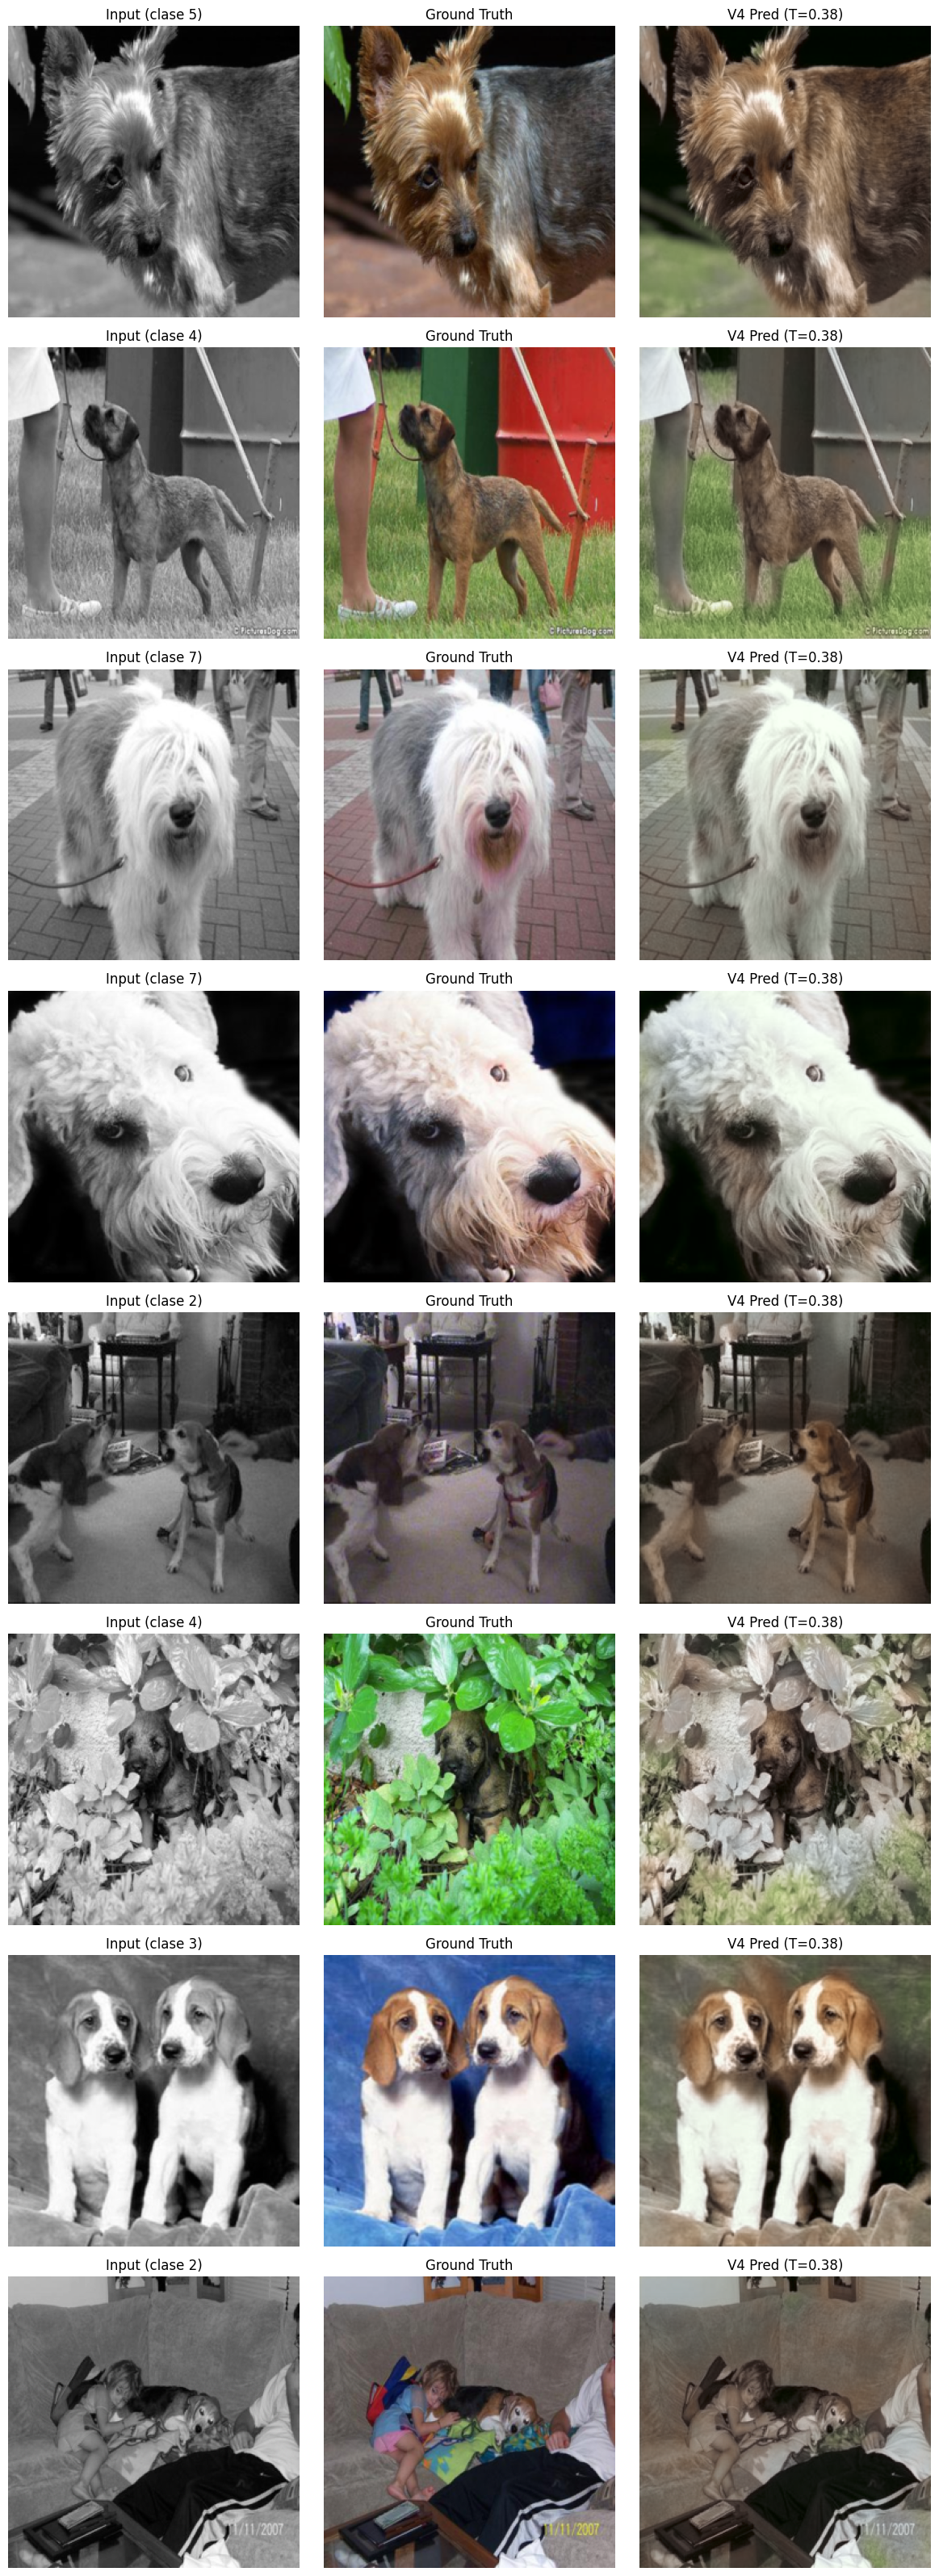

✅ Visualización guardada en 'results_v4_quantized.png'


In [ ]:
# %%
# PASO 8: Visualizar resultados V4 con decodificación annealed-mean

def visualize_v4_results(model, loader, pts_ab, device, n_samples=6, T=0.38):
    """
    Visualiza colorización de V4 con annealed-mean.
    """
    model.eval()
    
    L_batch, ab_batch, labels_batch = next(iter(loader))
    L_batch = L_batch[:n_samples].to(device)
    ab_batch = ab_batch[:n_samples].to(device)
    
    with torch.no_grad():
        color_logits, scene_logits = model(L_batch)
        ab_pred = decode_ab_annealed(color_logits, pts_ab.to(device), T=T)
    
    # LAB → RGB
    from skimage import color
    def lab_to_rgb_batch(L, ab):
        imgs = []
        for i in range(L.shape[0]):
            L_np = L[i, 0].cpu().numpy() * 100.0
            ab_np = ab[i].cpu().numpy()
            
            lab = np.stack([L_np, ab_np[0], ab_np[1]], axis=-1)
            rgb = color.lab2rgb(lab)
            rgb = np.clip(rgb, 0, 1)
            imgs.append(rgb)
        return imgs
    
    rgb_true = lab_to_rgb_batch(L_batch, ab_batch)
    rgb_pred = lab_to_rgb_batch(L_batch, ab_pred)
    
    # Plot
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    
    for i in range(n_samples):
        axes[i, 0].imshow(L_batch[i, 0].cpu(), cmap='gray')
        axes[i, 0].set_title(f'Input (clase {labels_batch[i].item()})')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(rgb_true[i])
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(rgb_pred[i])
        axes[i, 2].set_title(f'V4 Pred (T={T})')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    return fig

# Cargar mejor modelo
state_best = torch.load("best_model_v4_quantized.pth", map_location=device)
model_v4.load_state_dict(state_best)

print("Generando visualización V4...")
fig = visualize_v4_results(model_v4, val_loader_quant, pts_ab_torch, device, 
                           n_samples=8, T=0.38)
plt.show()

print(" Visualización guardada en 'results_v4_quantized.png'")

In [ ]:
# %%
# Comparar diferentes temperaturas T

temperatures = [0.1, 0.38, 0.7, 1.0]

state_best = torch.load("best_model_v4_quantized.pth", map_location=device)
model_v4.load_state_dict(state_best)

L_batch, ab_batch, labels_batch = next(iter(val_loader_quant))
L_batch = L_batch[:4].to(device)
ab_batch = ab_batch[:4].to(device)

fig, axes = plt.subplots(4, len(temperatures)+2, figsize=(4*(len(temperatures)+2), 16))

with torch.no_grad():
    color_logits, _ = model_v4(L_batch)
    
    for i in range(4):
        # Input
        axes[i, 0].imshow(L_batch[i, 0].cpu(), cmap='gray')
        axes[i, 0].set_title('Input')
        axes[i, 0].axis('off')
        
        # GT
        from skimage import color as skcolor
        L_np = L_batch[i, 0].cpu().numpy() * 100
        ab_np = ab_batch[i].cpu().numpy()
        lab_gt = np.stack([L_np, ab_np[0], ab_np[1]], axis=-1)
        rgb_gt = skcolor.lab2rgb(lab_gt)
        axes[i, 1].imshow(np.clip(rgb_gt, 0, 1))
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Diferentes temperaturas
        for j, T in enumerate(temperatures):
            ab_pred = decode_ab_annealed(color_logits[i:i+1], pts_ab_torch.to(device), T=T)
            ab_np_pred = ab_pred[0].cpu().numpy()
            lab_pred = np.stack([L_np, ab_np_pred[0], ab_np_pred[1]], axis=-1)
            rgb_pred = skcolor.lab2rgb(lab_pred)
            
            axes[i, j+2].imshow(np.clip(rgb_pred, 0, 1))
            axes[i, j+2].set_title(f'T={T}')
            axes[i, j+2].axis('off')

plt.tight_layout()
plt.show()